In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sklearn
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import normalize
plt.rcParams["figure.figsize"] = (5,4)
plt.rcParams["figure.dpi"] = 150
TICK_SIZE = 12
AXES_SIZE = 14
TITLE_SIZE = 14
FACECOLOR = 'white'
SCATTER_ALPHA = 0.5

plt.rc('font', size=TICK_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=AXES_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=AXES_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=TICK_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=TICK_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=TICK_SIZE)    # legend fontsize
plt.rc('figure', titlesize=TITLE_SIZE)  # fontsize of the figure title


In [31]:
# loads data :)
# features are - Average Job Power, Average Job Time, Average Job # Nodes, Number of Jobs, Utilization
#
# average job power and time were calculated as the mean of the mean of the 
# minimum and maximum power and time 
NORMALIZE = False
data_folder = 'numpy_data/'
feature_data = np.load(data_folder + 'sim_features.npy')
feature_qos = np.load(data_folder + 'features_qos.npy')
r_labels = np.load(data_folder + 'r_labels.npy')
p_labels = np.load(data_folder + 'p_labels.npy')

r_labels = np.reshape(r_labels,(18,1))
p_labels = np.reshape(p_labels,(18,1))
print(feature_qos.shape)
print(r_labels.shape)
print(p_labels.shape)
# concatenates everything
all_data = np.concatenate((feature_qos,p_labels,r_labels),axis=-1)

features = ['Mean Job Pow','Mean Job Time','Mean # Nodes','# Jobs','Util','Mean Qos','AQA P','AQA R']

(18, 6)
(18, 1)
(18, 1)


In [32]:
pearsons__matrix_r = np.corrcoef(all_data.T)

In [29]:
print(pearsons__matrix_r)

[[ 1.00000000e+00  4.41095836e-01  4.66718617e-02 -2.79740120e-01
   9.75736050e-20  1.63170077e-01  4.88439099e-01  4.76695520e-01]
 [ 4.41095836e-01  1.00000000e+00 -3.74434603e-01 -1.68119023e-01
  -4.70790844e-18 -5.83044366e-01  1.98163371e-01  3.63153359e-01]
 [ 4.66718617e-02 -3.74434603e-01  1.00000000e+00  6.69065659e-02
   2.55279118e-17  4.99783087e-01  1.28104100e-01 -1.25019926e-02]
 [-2.79740120e-01 -1.68119023e-01  6.69065659e-02  1.00000000e+00
   9.39181168e-18 -1.03377745e-01 -1.36369746e-01 -2.17980152e-01]
 [ 9.75736050e-20 -4.70790844e-18  2.55279118e-17  9.39181168e-18
   1.00000000e+00 -8.39639342e-18  7.81868156e-01  9.41619273e-02]
 [ 1.63170077e-01 -5.83044366e-01  4.99783087e-01 -1.03377745e-01
  -8.39639342e-18  1.00000000e+00  1.86105920e-01  3.75721978e-01]
 [ 4.88439099e-01  1.98163371e-01  1.28104100e-01 -1.36369746e-01
   7.81868156e-01  1.86105920e-01  1.00000000e+00  4.53651111e-01]
 [ 4.76695520e-01  3.63153359e-01 -1.25019926e-02 -2.17980152e-01
   

C:\Users\QSURFA~1\AppData\Local\Temp/ipykernel_21328/3688636588.py:3: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask = np.zeros_like(pearsons__matrix_r, dtype=np.bool)


Text(0.5, 1.0, 'Pearson R^2 Coorelation')

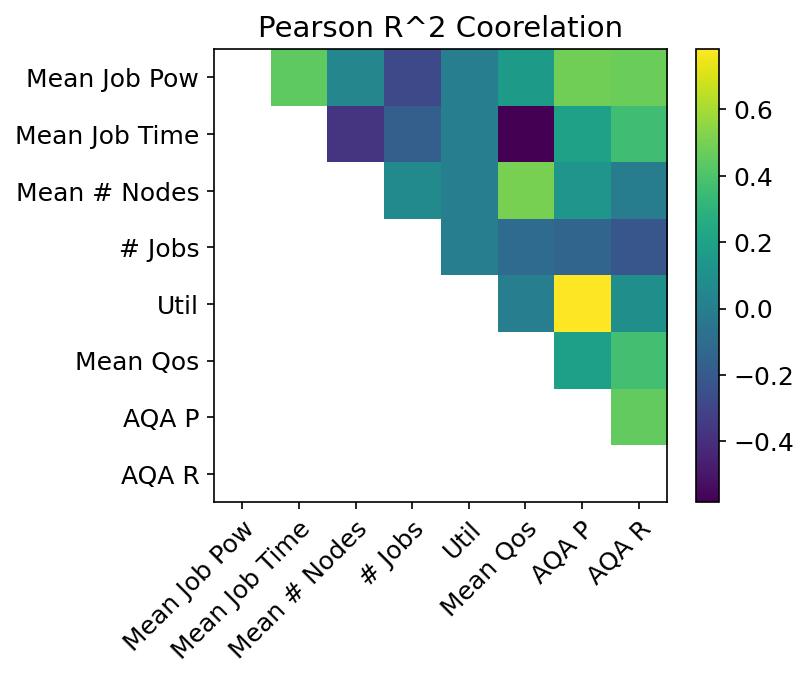

In [61]:
#plt.matshow(pearsons__matrix_r)

mask = np.zeros_like(pearsons__matrix_r, dtype=np.bool)
mask[np.tril_indices_from(mask)] = True


pearsons_plot = np.ma.array(pearsons__matrix_r, mask=mask)
fig,ax = plt.subplots()
#ax = plt.gca()
#plt.colorbar()
im = ax.matshow(pearsons_plot, interpolation='none')
fig.colorbar(im)

n = len(features)
ax.set_xticks(np.arange(n))
ax.set_xticklabels(features)
ax.set_yticks(np.arange(n))
ax.set_yticklabels(features)
ax.xaxis.set_ticks_position("bottom")
plt.setp(ax.get_xticklabels(), rotation=45,
         ha="right", rotation_mode="anchor")

plt.title('Pearson R^2 Coorelation')
#plt.xlabel(features,rotation=90)
#plt.xticks(rotation=90)
#plt.yticks(features)